<a href="https://colab.research.google.com/github/olyadiya/i_want_to_believe/blob/main/first_dataset_draft/draft_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Блок 1. Постановка задачи

В рамках своего проекта я плнирую собрать датасет, который можно использовать в исследованиях сентимент-анализа. Сейчас датасет находится на начальном этапе: в нем не так много данных и по своим критериям они распределяются неравномерно.

Целью этой работы можно поставить анализ датасета: наглядно показать его содержимое, чтобы посмотреть какие в нем есть пробелы, **что нужно делать для его улучшения**, помимо простого набирания текстов (возможно выявить критерии для сбора текстов, так как сейчас это по сути результат парсинга сабреддита). Визуализация поможет четко и явно определить пробелы. Также попробую провести небольшой анализ на тех данных, которые уже собраны.

Для такой задачи больше подойдет интеррактивный формат: он позволит посмотреть как общее состояние датасета, так и точечно выделить преимущества и недостоинства.



In [ ]:
dataset_description = "Датасет содержит 100 сообщений о наблюдениях НЛО. Датасет собирался в ручную с сабредита r/UFO (изначально собирала датасет для сентимент-анализа, для жтого задания увеличила его и решила использовать здесь. Для каждого сообщения есть текстовое описание, год наблюдения и страна."
research_question = "(Лингвистический) Анализ наблюдений очеведцев НЛО"
chosen_format = "interactive dashboard"

print(dataset_description)
print(research_question)
print(chosen_format)

Датасет содержит 100 сообщений о наблюдениях НЛО. Датасет собирался в ручную с сабредита r/UFO (изначально собирала датасет для сентимент-анализа, для жтого задания увеличила его и решила использовать здесь. Для каждого сообщения есть текстовое описание, год наблюдения и страна.
(Лингвистический) Анализ наблюдений очеведцев НЛО
interactive dashboard


# Блок 2. Загрузка библиотек



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Блок 3. Загрузка датаета



In [ ]:
df = pd.read_csv("/content/ufo_reports - reports.csv")

df.columns = df.columns.str.strip()

df["description"] = df["description"].fillna("")
df["text_length"] = df["description"].str.len() #к своим данным добавляю длинну текста
df["word_count"] = df["description"].str.split().str.len() #добавляю информацию о количестве слов в каждом репорте

df.head()

,id,description,year,country,text_length,word_count
0,1,Canadian air traffic controllers and pilots co...,2023,Canada,1090,173
1,2,"""I was taking a walk after dinner with my brot...",2022,USA,358,71
2,3,"""I live on the southwest side of Oahu, Hawaii....",2022,USA,801,150
3,4,"""On July 1, I was heading to work at 9 a.m., c...",2021,USA,417,79
4,5,"""I had to work at Glastonbury Festival this ye...",2022,England,910,170


ссылка на датасет: https://docs.google.com/spreadsheets/d/1ui8lQtIl8_iR1cLsNXV8GscC2VQ_4U8fKRmYfdKGn4I/edit?usp=sharing

# Блок 4. Быстрый обзор данных



In [ ]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nInfo:")
display(df.info())
print("\nMissing values:")
display(df.isna().sum())
display(df.head())


Shape: (100, 6)

Columns: ['id', 'description', 'year', 'country', 'text_length', 'word_count']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           100 non-null    int64 
 1   description  100 non-null    object
 2   year         100 non-null    int64 
 3   country      100 non-null    object
 4   text_length  100 non-null    int64 
 5   word_count   100 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 4.8+ KB


None


Missing values:


,0
id,0
description,0
year,0
country,0
text_length,0
word_count,0


,id,description,year,country,text_length,word_count
0,1,Canadian air traffic controllers and pilots co...,2023,Canada,1090,173
1,2,"""I was taking a walk after dinner with my brot...",2022,USA,358,71
2,3,"""I live on the southwest side of Oahu, Hawaii....",2022,USA,801,150
3,4,"""On July 1, I was heading to work at 9 a.m., c...",2021,USA,417,79
4,5,"""I had to work at Glastonbury Festival this ye...",2022,England,910,170


# Маршрут A. Интерактивная визуализация

Частотность слов в обращениях свидетелей


In [ ]:
from collections import Counter
import re

text = " ".join(df["description"].astype(str))

words = re.findall(r"\b[a-zA-Z]+\b", text.lower())

stopwords = {
    "the","a","an","and","or","to","of","in", "not", "one", "out",
    "said", "over", "her", "there", "you", "saw", "see", "after", "time",
    "can", "know", "looked", "them", "into", "could", "went",
    "on","at","for","with","was","were","is", "then", "have", "had",
    "are","it","that","this","i","we","they", "all", "like", "just",
    "he","she","my","our","their","from", "when", "what", "about", "but"
}

words = [w for w in words if w not in stopwords and len(w) > 2]

word_counts = Counter(words)

top_words = pd.DataFrame(word_counts.most_common(20), columns=["word","count"])

fig = px.bar(
    top_words,
    x="count",
    y="word",
    orientation="h",
    title="20 самых частых слов в описаниях НЛО"
)

fig.show()

При помощи запуска по нескольким итерациям отредактировала список стоп-слов, видим, что основной показатель описаний "неопределенность": встречаются слова с анологичной коннотацией - thing, something, anything, other.

Наиболее частые слова служат для описания обстоятельств, при которых были увидены НЛО: sky, light(s), night, moving

Для большей наглядности посмотрим также облако слов

In [ ]:
!pip install wordcloud

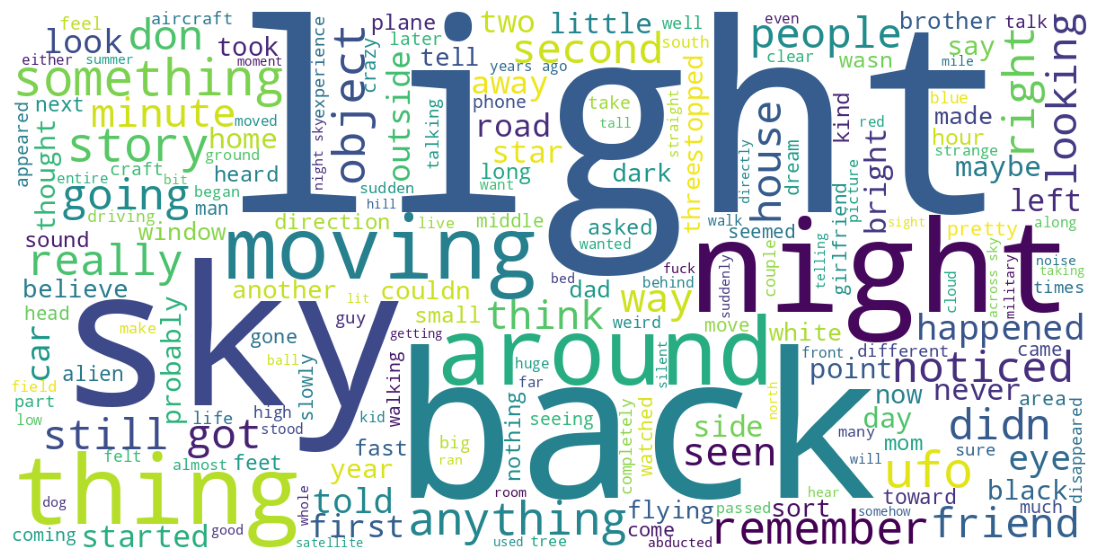

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white").generate(" ".join(words))

plt.figure(figsize=(14,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

Биграммы

In [ ]:
from collections import Counter
import re

tokens = re.findall(r'\b[a-z]+\b', text.lower())
stopwords = {
    "the","a","an","and","or","to","of","in", "not", "one", "out", "i", "am",
    "said", "over", "her", "there", "you", "saw", "see", "after", "time",
    "can", "know", "looked", "them", "into", "could", "went", "t", "as",
    "on","at","for","with","was","were","is", "then", "have", "had",
    "are","it","that","this","i","we","they", "all", "like", "just",
    "he","she","my","our","their","from", "when", "what", "about", "but"
}

filtered_bigrams = [
    (w1, w2) for w1, w2 in zip(tokens[:-1], tokens[1:])
    if w1 not in stopwords and w2 not in stopwords
]

bigram_counts = Counter(" ".join(b) for b in filtered_bigrams)

top_bigrams = pd.DataFrame(bigram_counts.most_common(15), columns=["bigram", "count"])

fig = px.bar(
    top_bigrams,
    x="count",
    y="bigram",
    orientation="h",
    title="Самые частые биграммы"
)
fig.show()

Здесь уже видим элементы описания истории: years ago, years old, ever seen и тд.

Попробуем вывести обращения, нагруженные эмоциональным контекстом. К таким маркерам высокого уровня эмоций поставим: слова написанные заглавными буквами, частое употребление восклицательных знаков, обсценная лексика (в данном случае посмотрим именно на словоформы "fuck")

In [ ]:
df["description"] = df["description"].fillna("")

#количество !
df["exclamation_count"] = df["description"].str.count(r"!")

#наличие CAPSLOCK
df["has_caps"] = df["description"].apply(lambda x: bool(re.search(r"\b[A-Z]{3,}\b", str(x))))

#наличие обсценной лексики
df["has_swear"] = df["description"].str.contains(
    r"\bfuck(?:ing|ed)?\b", case=False, regex=True)

#общий фон эмоционального текста
df["emotional_text"] = (
    (df["exclamation_count"] > 4)
    | (df["has_caps"])
    | (df["has_swear"])
)

emotional_reports = df[df["emotional_text"]]

#распределеяю по годам
emotional_by_year = (emotional_reports.groupby("year").size().reset_index(name="reports"))

emotional_reports[
    [   "year",
        "country",
        "exclamation_count",
        "has_caps",
        "has_swear",
        "description"
    ]
].head(20)

,year,country,exclamation_count,has_caps,has_swear,description
0,2023,Canada,0,True,False,Canadian air traffic controllers and pilots co...
2,2022,USA,0,True,False,"""I live on the southwest side of Oahu, Hawaii...."
10,2000,USA,0,True,False,"""I grew up on a ranch in West Texas. I was in ..."
11,2012,USA,0,True,False,"""This was my first time seeing anything I legi..."
14,2000,USA,0,True,False,"""I was seven stories up and stepped outside on..."
16,2010,USA,0,True,False,"The best case that I had ever worked with, and..."
17,1975,USA,0,True,False,When I had looked into the very first case tha...
20,1986,USA,0,True,False,"In another case, on Long Island a woman who I'..."
24,2010,USA,0,True,True,I was driving home for the weekend from school...
26,2013,USA,0,True,False,I was traveling back home with my mom from my ...


Сопоставим эти данные с датой произошедших случаев.

In [ ]:
fig = px.bar(
    emotional_by_year,
    x="year",
    y="reports",
    title="Эмоционально окрашенные сообщения по годам"
)

fig.update_layout(xaxis_title="Год", yaxis_title="Количество сообщений")

fig.show()

можно проследить корреляцию: чем более "свежее" воспоминаните, тем сильнее его эмоциональная нагрузка

## Задание A2
Динамика количества сообщений по годам: сначала проверим есть ли рост обращений по годам (хотя с таким относительно небольшим датасетом не будет сильной статистической значимости, даже если закономерность будет прослеживаться).

In [ ]:
reports_by_year = (df.groupby("year").size().reset_index(name="reports")) #считаем сообщения по годам

country_info = (df.groupby(["year", "country"]).size().reset_index(name="count"))

hover_text = (country_info.groupby("year").apply(
        lambda x: "<br>".join(
            [f"{row['country']}: {row['count']}"
             for _, row in x.iterrows()]
        )
    )
    .reset_index(name="countries")
)

reports_by_year = reports_by_year.merge(hover_text, on="year", how="left")

fig = px.line(
    reports_by_year,
    x="year",
    y="reports",
    markers=True,
    title="Количество сообщений о НЛО по годам"
)
#добавляю по странам и сортирую по годам
fig.update_traces(
    customdata=reports_by_year[["countries"]],
    hovertemplate=
    "<b>Год:</b> %{x}<br>" +
    "<b>Всего сообщений:</b> %{y}<br><br>" +
    "<b>По странам:</b><br>%{customdata[0]}" +
    "<extra></extra>"
)

fig.update_layout(xaxis_title="Год", yaxis_title="Количество сообщений")

fig.show()

/tmp/ipykernel_5778/1221421240.py:5: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [ ]:
interactive_explanation = '''Как и предполагалось, корреляции нет. Линейный график показывает изменение количества сообщений во времени.
Интерактивный формат позволяет исследовать конкретные годы и сравнивать периоды повышенной активности сообщений.
При этом на графике очевидно видны пики обращеший: 2000-ый год и 2013. В данном случае это объясняется тем,
что сам сабреддит был создан в 2013 году и большинстов людей рассказывали либо недавние истории, либо истории примерно 10-летней давности,
что отсылало по датировке на примерно 2000-ый год.
'''
print(interactive_explanation)

Как и предполагалось, корреляции нет. Линейный график показывает изменение количества сообщений во времени.
Интерактивный формат позволяет исследовать конкретные годы и сравнивать периоды повышенной активности сообщений.
При этом на графике очевидно видны пики обращеший: 2000-ый год и 2013. В данном случае это объясняется тем,
что сам сабреддит был создан в 2013 году и большинстов людей рассказывали либо недавние истории, либо истории примерно 10-летней давности,
что отсылало по датировке на примерно 2000-ый год.



Посмотрим есть ли зависимость между количеством слов и годом описания, то есть попробуем ответить на вопрос - стали ли со врменем люди писать более подробные описания.

In [ ]:
fig = px.box(
    df,
    x="year",
    y="word_count",
    title="Длина описаний по годам"
)

fig.show()

За исключением нескольких "выбросов", нельзя сделать вывод о том, что сообщения стали длинее с течнием времени. Самые длинные сообщения выпадают на период середины 90-х, эмпирически можно отметить, что большинство таких историй - пересказы родственников-свидетелей НЛО (то есть скорее всего, это давние "отрепетированные" aka много раз расказанные истории).

# Блок 8. Финальное пояснение к работе


В данном исследовании мы смогли проанализировать тексты обращений очевидцев НЛО. Датасет был собран вручную и пока находится на этае доработки, поэтому значимых результатов не было получено.

Был выбран формат интеррактивных графиков в том числе, чтобы вывести данные и посмотреть какие пробелы нужно восполнить в данных, чтобы анализ такого датасет отражал полную картину. Например, график количества сообщений об НЛО по годам не показал корреляции, но при этом сами данные распределны неравномерно, из-за того что сабреддит был создан в 2013 году, большинство обращений датируются именно этим годом.

Данные по странам тоже стоит распредилить в другом виде: так как сабреддит на американском сегменте - по умолчанию очевидцы из Америки, возможно стоит собрать информацию по штатам.

При этом визуализация по анализу текста хорошо демонстрирует основные семы, которые иллюстрируют чувсвста свидетелей, в большинстве случаев - неопределенность (через использование неопрделенных местоимений).

Визуализация по биграммам, также демонстрирует, что большинство историй пишутся как воспоминания ("years ago", "[i was] years old"). В таких текстах эмоциональный окрас в целом сильно меньше, чем в относительно недавних, соответсвенно, слишком давние тексты не стоит брать в основную выборку для сентимент анализа.

Основной вывод, который можно сделать: датасет нуждается в доработке и большем наборе данных, при этом есть возможность сузить выборку текстов для более тщательного анализа:
- оставить тексты только от пользователей из Америки и по возможности указывать штат;
- дата "встречи" с НЛО должна быть как можно ближе к дате публикации текста, чтобы сентимент анализ представлял большую значимость;
- по возможности "выровнять" данные по датам публикации или скратить выборку по датам.